# **AI** **221** **project**

---

| Student Name   | ID       | Data Processing Task                                               | Data Analysis Task                                       | Data Visualization Task                          |
|:---------------|:--------:|:------------------------------------------------------------------|:--------------------------------------------------------|:------------------------------------------------|
| Reem Ghanem    | 4555592  |Cleaned, standardized and normalized the Major column by grouping similar majors|Finding Common Categories (Frequency Analysis) in Majors |Visualizing Major Frequencies (Bar Chart) |
Lamees ahmed |4550810|handing missing data, and duplicates|Correlation Analysis for Question 10|Heatmap Visualization for Question 10, Plot displaying victim counts across different skill levels|
| Maryam Adel    |  4551460 |  Tokenizing text data: the top 3 purposes for using internet, and Normalization by encoding      | Finding central values (mean, median, mode)|  pie chart for age column|
 | Latifa Mohammed    | 4550828  |  Standardize text for Digital Skills, Education Level, and Regions.| Crosstabs to compare Digital Skills by Region.|   Box plot of Age Midpoints.|
 | Dorar ali | 4552585 |Encoding the opinion columns (Q10) | Aggregation the administrative region  with the victims columns | Histogram for age columns with victims columns

 we have survey dataset focused on evaluating individuals' Digital Usage Patterns and their level of Cybersecurity Awareness.

**Demographic Data:** Basic information about the respondents, such as Gender, Age, Education Level, and Major.

**Digital Usage Patterns:** Details on how often participants use the Internet, their reported digital skills level, and the main purposes for their online activity.

**Cybersecurity Awareness:** Responses measuring the participants' concern levels regarding common cyber threats and risks (e.g., identity theft, phishing emails, and inability to access online services).

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

In [35]:
#read the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Lamees56l/AI-221-project-dataset/refs/heads/main/Dataset.csv")

In [36]:
#print the header of the data before cleaning
df.head(5)

,1) Gender,2) Age,3) Education Level,4) Major,5) administrative regions,"6) How often do you use the Internet and Internet-related services? (E.g. Email, WhatsApp, News, YouTube",7) What are your Internet/ Digital devices skills level?,"8) Of the following, which digital devices do you use regularly? Tick all that apply",9) For what purposes do you use the Internet? Tick all that apply,"10) Some of the most common cyber crimes are presented below. What is your opinion of each of the following statements? Select the appropriate response for each [I am concerned about identity theft (somebody stealing your personal data and impersonating you, e.g. tweeting under your name)]",...,10) Some of the most common cyber crimes are presented below. What is your opinion of each of the following statements? Select the appropriate response for each: [I am concerned about not being able to access online services (e.g. banking services) because of cyber attacks],10) Some of the most common cyber crimes are presented below. What is your opinion of each of the following statements? Select the appropriate response for each: [I am concerned about accidentally encountering material that promotes hatred or religious extremism],"10) Some of the most common cyber crimes are presented below. What is your opinion of each of the following statements? Select the appropriate response for each: [Online extortion (a demand for money to avert or stop extortion, or to avert scandal)]","Other, please specify","Other, please specify.1","11) Have you been a victim of cyber crime? (E.g. lost data or email account, device infected with virus or spyware, stole your picture/s or digital device/s).","If Yes, To whom did you report or contact? (Please check all that apply)","If No, What was/were the reason/s? (Please check all that apply)","If Yes, To whom would you report or contact? (Please check all that apply)","If No, What is/are the reason/s? (Please check all that apply)"
0,Female,18-29,"Postgraduate (Masters, PhD)",Computer Science,NaN,Frequently throughout the day,Intermediate (e.g. able to install and run spe...,"Desktop, Laptop, Smartphone","Education, Social networks, Online services, C...",Always,...,Always,Always,Always,NaN,NaN,Yes,NaN,I think that there is no value of reporting,NaN,I do not know what the crime means
1,Female,18-29,"Undergraduate (Diploma, BSc)",Medicine or public health,NaN,Frequently throughout the day,Intermediate (e.g. able to install and run spe...,Smartphone,"Social networks, Communication",Never,...,Never,Never,Never,NaN,NaN,No,NaN,NaN,"Saudi eGovernment Portal , Saudi CERT",NaN
2,Female,18-29,"Undergraduate (Diploma, BSc)",Medicine or public health,NaN,Frequently throughout the day,Intermediate (e.g. able to install and run spe...,Tablet,"Education, Social networks, Online services, C...",Somtimes,...,Sometimes,Sometimes,Sometimes,NaN,NaN,Yes,Bank,NaN,NaN,Not sure
3,Female,18-29,"Undergraduate (Diploma, BSc)",Medicine or public health,NaN,Frequently throughout the day,Intermediate (e.g. able to install and run spe...,"Laptop, Smartphone","Professional reasons, Education, Social networ...",Never,...,Always,Always,Always,NaN,NaN,No,NaN,NaN,NaN,Not sure
4,Male,18-29,"Undergraduate (Diploma, BSc)",Engineering,NaN,Frequently throughout the day,Intermediate (e.g. able to install and run spe...,"Desktop, Laptop, Smartphone","Education, Social networks, Online services, E...",Always,...,Sometimes,Always,Sometimes,NaN,NaN,Yes,NaN,I did not know how to describe or write report...,NaN,I will fix the problem by myself


# **Data Processing**



To make the data easier to access view and manipulate, we will change the column names

In [37]:
df.columns =['1)Gender' ,'2)Age','3)Education Level', '4)Major','5)administrative regions','6)Internet usage','7)Digital Skills','8)digital devices' , '9)Internet Purpose'
             , '10)Identity theft concern' , '10)Online services attack' ,'10)phishing emails', '10)Hate/extremism content' , '10)Online extortion' ,'Other, please specify','Other, please specify.1'
             , '11)Have you been a victim of cyber crime?' , 'If Yes, To whom did you report or contact?','If No, What was/were the reason/s?','If Yes, To whom would you report or contact?','If No, What is/are the reason/s?']

df.columns

Index(['1)Gender', '2)Age', '3)Education Level', '4)Major',
       '5)administrative regions', '6)Internet usage', '7)Digital Skills',
       '8)digital devices', '9)Internet Purpose', '10)Identity theft concern',
       '10)Online services attack', '10)phishing emails',
       '10)Hate/extremism content', '10)Online extortion',
       'Other, please specify', 'Other, please specify.1',
       '11)Have you been a victim of cyber crime?',
       'If Yes, To whom did you report or contact?',
       'If No, What was/were the reason/s?',
       'If Yes, To whom would you report or contact?',
       'If No, What is/are the reason/s?'],
      dtype='object')

**1- Handling Missing Values**

---



We can see that the dataset contains many missing values so the columns with more than 20% missing data will be removed

In [38]:
#show the number of missing values
df.isna().sum()

,0
1)Gender,20
2)Age,18
3)Education Level,32
4)Major,126
5)administrative regions,100
6)Internet usage,13
7)Digital Skills,20
8)digital devices,13
9)Internet Purpose,0
10)Identity theft concern,0


<Axes: >

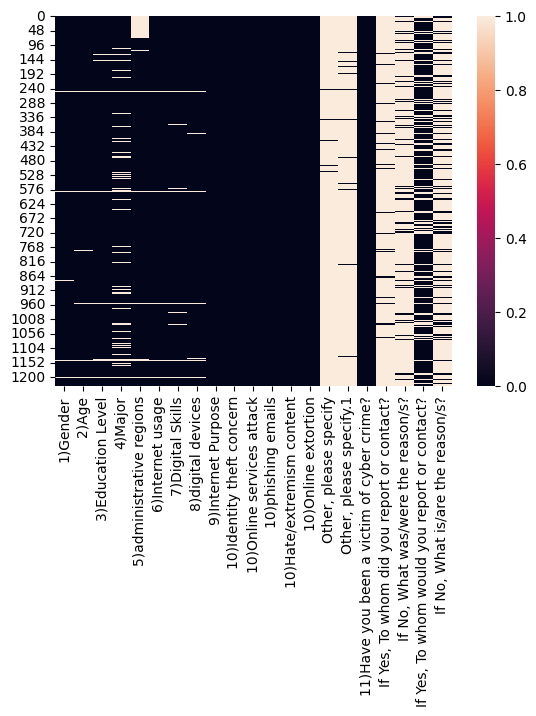

In [39]:
sns.heatmap(df.isnull())

In [40]:
class dataCleaner:

  def __init__(self,dataf):
    self.dataf = dataf

  def delete_column(self,dataf):
    '''take every column and delete it if the none values are more than 20% of the column'''
    empty_column =[]
    row= len(dataf)
    for column in dataf.columns: #loop through each column in the df
      empty_value = 0

      for v in dataf[column]:    #loop in every value in the column if the value is null add 1 to empty
        if str(v) == 'nan' or v == None:
          empty_value +=1

      ratio = empty_value / row  #Calculate the ratio of empty values to the whole row
      if ratio > 0.20:           #if the ratio is more than 20% then its added to the empty_columns list to be deleted
        empty_column.append(column)

      if column in empty_column:
        del dataf[column]
    print(f'number of columns that got deleted {len(empty_column)}')


  def delete_rows(self , dataf):
    '''removes the rows that contains any missing values in any column '''

    clean_rows =[]

    for i in range(len(df)):
        row = dataf.iloc[i]  #locate the row
        isnull = any(str(val) == 'nan' or val is None for val in row)
        if not isnull:       #if the data has no nan values
          clean_rows.append(i)

    print(f'number of rows that got deleted {len(dataf)-len(clean_rows)}')
    return dataf.iloc[clean_rows] #return a new df that contains only the rows that has no missing data


In [41]:
data= dataCleaner(df)
data.delete_column(df)
df =data.delete_rows(df)
df.shape

number of columns that got deleted 6
number of rows that got deleted 238


(992, 15)

In [42]:
df.isna().sum()

,0
1)Gender,0
2)Age,0
3)Education Level,0
4)Major,0
5)administrative regions,0
6)Internet usage,0
7)Digital Skills,0
8)digital devices,0
9)Internet Purpose,0
10)Identity theft concern,0


**2- Dealing With Duplicated Data**

---

In [44]:
duplicated = df.duplicated()
duplicated.sum()

np.int64(30)

In [45]:
#show duplicated
df[duplicated].sort_values(by = ['1)Gender','2)Age','3)Education Level']).head(10)

,1)Gender,2)Age,3)Education Level,4)Major,5)administrative regions,6)Internet usage,7)Digital Skills,8)digital devices,9)Internet Purpose,10)Identity theft concern,10)Online services attack,10)phishing emails,10)Hate/extremism content,10)Online extortion,11)Have you been a victim of cyber crime?
322,Female,18-29,High School,Physics,Makkah,Frequently throughout the day,Beginner/Basic,Smartphone,"Education, Social networks, Entertainment, Com...",Somtimes,Sometimes,Sometimes,Sometimes,Sometimes,No
589,Female,18-29,Undergraduate,Languages,Riyadh,Frequently throughout the day,Intermediate,"Desktop, Laptop, Smartphone, Tablet","Education, Social networks, Online services, C...",Never,Always,Always,Always,Always,Yes
706,Female,18-29,Undergraduate,Computer Science,Makkah,Frequently throughout the day,Intermediate,"Laptop, Smartphone","Education, Social networks, Online services, E...",Always,Always,Always,Always,Always,No
846,Female,18-29,Undergraduate,Physics,Makkah,Frequently throughout the day,Intermediate,Smartphone,Social networks,Always,Always,Always,Always,Always,No
918,Female,18-29,Undergraduate,Islamic studies,Makkah,Frequently throughout the day,Intermediate,Smartphone,Social networks,Always,Always,Always,Always,Always,Yes
984,Female,18-29,Undergraduate,Arabic Language,Makkah,Frequently throughout the day,Beginner/Basic,Smartphone,Social networks,Always,Always,Always,Always,Always,No
1030,Female,18-29,Undergraduate,Physics,Makkah,Frequently throughout the day,Beginner/Basic,Smartphone,Social networks,Always,Always,Always,Always,Always,No
1083,Female,18-29,Undergraduate,Islamic studies,Makkah,Frequently throughout the day,Beginner/Basic,Smartphone,Social networks,Always,Always,Always,Always,Always,No
1103,Female,18-29,Undergraduate,Computer Science,Makkah,Frequently throughout the day,Intermediate,Smartphone,Social networks,Always,Always,Always,Always,Always,Yes
1107,Female,18-29,Undergraduate,Computer Science,Makkah,Frequently throughout the day,Intermediate,Smartphone,Social networks,Always,Always,Always,Always,Always,No


We can see that the duplicates are not a full match. Because it is survey data, this is normal so the rows will be kept

**3- Reformatting**


---
Standardizes the format of a text column by cleaning and normalizing string **values**


In [43]:
SKILL_COL = '7)Digital Skills'
EDU_COL = '3)Education Level'
REGION_COL ='5)administrative regions'


def clean_text( COL):
    """Removes text in parentheses from the column and strips whitespace.
  Prints the value counts for the cleaned column to show the results
  """
    pattern = r'\s*\(.*\)'
    df[COL] = df[COL].str.replace(pattern, '', regex=True).str.strip()
    print(f"\n--- Cleaning Results for '{COL}' ---")
    print(df[COL].value_counts())

def normalize_column(column_name):
    """Strips whitespace and converts the column data to Title Case for standardization.
  Prints the value counts for the normalized column
  """
    df[column_name] = df[column_name].str.strip()
    df[column_name] = df[column_name].str.title()
    print(f"\n--- Cleaning Results for '{column_name}' ---")
    print(df[column_name].value_counts())

clean_text(SKILL_COL)
clean_text(EDU_COL)
normalize_column(REGION_COL)


--- Cleaning Results for '7)Digital Skills' ---
7)Digital Skills
Intermediate      635
Beginner/Basic    221
Expert            136
Name: count, dtype: int64

--- Cleaning Results for '3)Education Level' ---
3)Education Level
Undergraduate    736
Postgraduate     166
High School       90
Name: count, dtype: int64

--- Cleaning Results for '5)administrative regions' ---
5)administrative regions
Makkah              659
Riyadh              102
Eastern Province     82
Madina               46
Asir                 32
Tabuk                21
Qassim               19
Baha                 15
Jazan                 6
Aljawf                4
Ha'Il                 2
Northern Borders      2
Najran                2
Name: count, dtype: int64


/tmp/ipython-input-1379895790.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[COL] = df[COL].str.replace(pattern, '', regex=True).str.strip()
/tmp/ipython-input-1379895790.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[COL] = df[COL].str.replace(pattern, '', regex=True).str.strip()
/tmp/ipython-input-1379895790.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

**4- Standardized And Normalized Major Column**


---



 We can see that the majors column is inconsistent – some entries have extra punctuation, different capitalization, typos, or multiple formats for the same major, which will affect counting and visualization.

In [46]:
#Print unique values of `Major`
print(len(df['4)Major'].unique()))
df['4)Major'].unique()

68


array(['Education"', 'Education.', 'Languages()', 'Computer Science',
       'Engineering', 'Islamic studies', 'Languages', 'Education',
       'Medicine or public health', 'Biology', 'Statics',
       'Business Administration', 'Social Science', 'Media', 'Chemsitry',
       'Finance', 'Arabic Language', 'Aviation', 'Islamic economy',
       'Mechanic- Prpducing Department', 'Islamic-studies',
       'Software Engineering', 'Math.', 'Library Adminstration',
       "Education'", 'Computer -Science', 'Law', 'Information System',
       'Designing', 'Environmental Sciences', 'Environmental Science',
       'Physics', 'Information Technology', 'Automotaive Mechanics',
       'Economic', 'Islamic studies.', '(Social Science)',
       'Business-Administration', 'Arts.', 'Science of Hadith', 'Math',
       'Chemistry', 'Science', 'Information and Libraries',
       'Graphic design', 'Arabic-Language', 'Pure Science',
       'Actuarial Science', 'Applied math', 'Natural Science',
       'Labor

 We cleaned the '4)Major' column and fixed inconsistencies for easier counting and visualization




In [47]:
befor = df['4)Major'].iloc[110:135]

def cleaning_major(df):
  """
  Clean the '4)Major' column by removing special characters and mapping
   majors to simple unified categories

   Steps:
   1. Convert values to string
   2. Capitalize words
   3. Remove extra spaces
   4. Remove special characters
   5. Map majors to simple unified categories
   6. Print unique values after cleaning
   """

  # Convert values to string, capitalize words and remove extra spaces
  df['4)Major'] = df['4)Major'].astype(str).str.title().str.strip()
  # Remove special characters
  df['4)Major'] = df['4)Major'].str.replace('"', '', regex=False)
  df['4)Major'] = df['4)Major'].str.replace('-', '', regex=False)
  df['4)Major'] = df['4)Major'].str.replace('(', '', regex=False)
  df['4)Major'] = df['4)Major'].str.replace(')', '', regex=False)
  df['4)Major'] = df['4)Major'].str.replace('.', '', regex=False)
  df['4)Major'] = df['4)Major'].str.replace("'", '', regex=False)


  mappings = {'Arabic Language' :'Languages' ,
             'English' : 'Languages',
             'English Language': 'Languages',
              'ArabicLanguage':'Languages',
              'Statics':'Math',
              'Applied Math':'Math',
              'BusinessAdministration':'Business & Finance ' ,
              'Business Administration':'Business & Finance',
              'Economic':'Business & Finance',
              'Finance':'Business & Finance',
              'IslamicStudies':'Islamic Economy',
              'Actuarial Science':'Actuarial Science',
              'Computer Science':'Computer Science & IT',
              'Natural Science': 'Science',
              'Pure Science': 'Science',
              'Software Engineering':'Computer Science & IT',
               'Information Technology':'Computer Science & IT',
              'Compute Science':'Computer Science & IT',
              'Aviation':'Engineering',
              'Mechanic Prpducing Department':'Engineering',
              'Medicine Or Public Health': 'Health & Medicine',
              'Laboratory Water Quality': 'Health & Medicine',
              'Science Of Hadith': 'Islamic Studies',
              'Interial Designing' : 'Media & Arts & Design',
              'Designing':'Media & Arts & Design',
              'Media':'Media & Arts & Design',
              'Arts':'Media & Arts & Design',
              'Graphic Design':'Media & Arts & Design',
              }
  df['4)Major'] = df['4)Major'].replace(mappings)


cleaning_major(df)
after = df['4)Major'].iloc[110:135]

# Compare the values before and after cleaning to verify the changes.
print(pd.concat([befor,after], axis = 1, keys=['--Before--','--After--'   ]))

                    --Before--              --After--
192                      Math.                   Math
193                Engineering            Engineering
194                    Biology                Biology
195           Computer Science  Computer Science & IT
196           Computer Science  Computer Science & IT
197    Business Administration     Business & Finance
198                  Education              Education
199      Library Adminstration  Library Adminstration
200                 Education'              Education
201                  Education              Education
202           Computer Science  Computer Science & IT
204                  Languages              Languages
205           Computer Science  Computer Science & IT
206           Computer Science  Computer Science & IT
207                  Education              Education
208  Medicine or public health      Health & Medicine
209           Computer Science  Computer Science & IT
210           Computer Scien

/tmp/ipython-input-2467655717.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['4)Major'] = df['4)Major'].astype(str).str.title().str.strip()
/tmp/ipython-input-2467655717.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['4)Major'] = df['4)Major'].str.replace('"', '', regex=False)
/tmp/ipython-input-2467655717.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [48]:
# After cleaning 'major'
len(df['4)Major'].unique())

36

In [49]:
df['4)Major'].unique()

array(['Education', 'Languages', 'Computer Science & IT', 'Engineering',
       'Islamic Studies', 'Health & Medicine', 'Biology', 'Math',
       'Business & Finance', 'Social Science', 'Media & Arts & Design',
       'Chemsitry', 'Islamic Economy', 'Library Adminstration', 'Law',
       'Information System', 'Environmental Sciences',
       'Environmental Science', 'Physics', 'Automotaive Mechanics',
       'Business & Finance ', 'Chemistry', 'Science',
       'Information And Libraries', 'Actuarial Science', 'Literature',
       'General Administration', 'Counting', 'Special Education',
       'Psychology', 'History', 'Administrative Sciences',
       'Applied Science', 'Preuniversity', 'Kindergarden', 'Sport'],
      dtype=object)

**5- Encoding**

---

1- converting 'Yes', 'No' answers of cyber crime victimization to binary 1/0 values.

In [50]:
a='11)Have you been a victim of cyber crime?'

df[a] = df[a].replace('Yes',1)
df[a] = df[a].replace('No',0)
df[a].head()

/tmp/ipython-input-1159819498.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[a] = df[a].replace('Yes',1)
/tmp/ipython-input-1159819498.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[a] = df[a].replace('No',0)
/tmp/ipython-input-1159819498.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

,11)Have you been a victim of cyber crime?
71,0
72,0
73,0
75,1
76,0






2- convert text answers in questions(10) into numbers so they can be analyzed more easily

In [51]:
target_col = df.columns[9:14] #get the text columns

#dictionary that converts the text answers into numbers
mapping= {
    "Always" : 3,
    "Sometimes" : 2,
    "Somtimes" : 2,
    "Never" : 1,
    "Do not know" : 0
}
#replac the selected columns with the dicionary
df[target_col]=df[target_col].replace(mapping)
df[target_col].head()

/tmp/ipython-input-2718154788.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_col]=df[target_col].replace(mapping)
/tmp/ipython-input-2718154788.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[target_col]=df[target_col].replace(mapping)


,10)Identity theft concern,10)Online services attack,10)phishing emails,10)Hate/extremism content,10)Online extortion
71,2,2,2,2,2
72,1,3,3,3,3
73,3,3,3,3,3
75,3,3,3,3,3
76,3,3,3,3,3


 **6- Tokenizing**

---

we'll find the top 3 common purposes for using the internet

In [52]:
def purposes_proc(column):
  """
  create dictionary of purposes and their occurrences

   Steps:
   1. convert to string
   2. Split purposes by commas
   3. remove space from both ends
   4. convert to lower case
   5. add values into list
   6. count the appearance of each purpose
   """
  All_purposes = []
  for p in column:
        value = [i.strip().lower() for i in str(p).split(',')]
        All_purposes.extend(value)

  purpose_counter = {}
  for p in All_purposes:
      if p in purpose_counter:
        purpose_counter[p]+=1
      else:
        purpose_counter[p]=1

  return  purpose_counter

a='9)Internet Purpose'
purpose_counter = purposes_proc(df[a]) #{'education': 633}

#to sort dictionary in descending order
sortedDict= {i:n for i,n in sorted(purpose_counter.items(),key=lambda a: a[1], reverse=True)} #[('education', 633)]. 633 is a[1]

#to calculate the total purposes overall
total=0
for i in purpose_counter:
  total+=purpose_counter[i]

print("Top 3 purposes for using the internet:")
counter=0
for purpose, count in sortedDict.items():
  if counter<3 :
    percent = (count / total) * 100
    print(f"{purpose} : {percent:.2f}%")
    counter+=1

Top 3 purposes for using the internet:
social networks : 26.07%
education : 19.44%
communication : 18.91%


<function matplotlib.pyplot.show(close=None, block=None)>

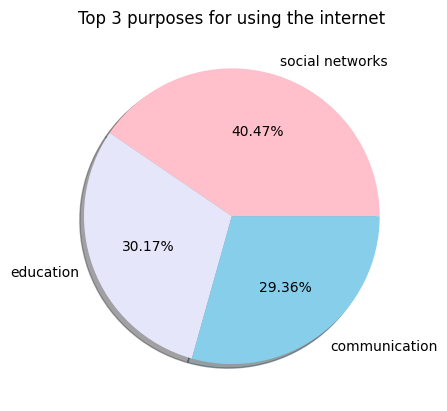

In [53]:
#pie chart showing the top 3 purposes in categories
sorted_purposes = sorted(purpose_counter.items(), key=lambda x: x[1], reverse=True)
top3 = sorted_purposes[:3]
main_purposes, purposes_freq = zip(*top3)

colors = (  "pink", "lavender","skyblue")

plt.pie(purposes_freq, labels=main_purposes, autopct='%1.2f%%',
        colors=colors, shadow=True)
plt.title("Top 3 purposes for using the internet")
plt.show

# **Data Analysis**



**1- Central Values**

---

we'll find the central values (mean, mode, median) for age column

In [54]:
def midpoint(age_str):
  """
  -calculate the midpoints of age intervals into unique value
   Steps:
   1. convert to string
   2. partition to split string into 3tuples
   2. convert to integer
   3. calculate midpoint

  -for non-intervals to convert into unique value
  Steps:
   1. remove any extra symbols
   2. convert to integer
   """
  age_str = str(age_str)

  if '-' in age_str:
    val1, dash, val2 = age_str.partition('-')
    n1 = int(val1)
    n2 = int(val2)
    return (n1 + n2) / 2

  elif '+' in age_str:
    n = int(age_str.replace('+', ''))
    return n
  else:
    return 0

df['midpoints']= df['2)Age'].map(midpoint)
print(f"The average age: {df['midpoints'].mean():.2f} years")
print(f"The most frequent age: {df['midpoints'].mode().iloc[0]:.2f} years") #'iloc'cuz of many diff modes
print(f"Median age: {df['midpoints'].median():.2f} years")

The average age: 30.56 years
The most frequent age: 23.50 years
Median age: 23.50 years


/tmp/ipython-input-3734626404.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['midpoints']= df['2)Age'].map(midpoint)


**2- Frequency Analysis**


---


We designed the major_counting function to count the occurrences of each major in the 4)Major column of the DataFrame. We then aggregate any majors that appear only once into a single “other” category. This approach helps us simplify the major distribution by grouping less frequent entries.

In [55]:
def major_counting(df):
  """
  Count how many times each major shows up and put the rare ones under
   'other'

   Steps:
   1. Create an empty dictionary to store major counts
   2. Loop through each major in the '4)Major' column
   3. If the major is already in the dictionary, increment its count by 1
   4. If the major is not in the dictionary, add it with a count of 1
   5. Create a list of majors that appear only once
   6. Replace these rare majors with the 'other' category
   7. Print the counts of each major
   """
  major_count = {}
  for major in df['4)Major']:
      if major in major_count:
            major_count[major] += 1
      else:
            major_count[major] = 1
  other_major=[key for key, value in major_count.items() if value == 1]
  major_count['other'] = len(other_major)

  for key in other_major:
    del major_count[key]

  return major_count

major_counting(df)

{'Education': 199,
 'Languages': 100,
 'Computer Science & IT': 274,
 'Engineering': 68,
 'Islamic Studies': 37,
 'Health & Medicine': 79,
 'Biology': 8,
 'Math': 25,
 'Business & Finance': 58,
 'Social Science': 51,
 'Media & Arts & Design': 9,
 'Chemsitry': 18,
 'Islamic Economy': 2,
 'Law': 8,
 'Physics': 21,
 'Science': 5,
 'Information And Libraries': 2,
 'General Administration': 4,
 'Counting': 6,
 'History': 2,
 'other': 16}



**3- Grouping**


---




Calculates the frequency of skill levels per region and displays the result as a cross-tabulation table.

In [56]:
def analyze_skill_dist(df, REGION_COL, SKILL_COL):
  """Analyze the distribution of skills across administrative regions"""

  freq = df[[REGION_COL, SKILL_COL]].value_counts().reset_index(name='Count')
  dist_table = freq.pivot(
      index=REGION_COL,
      columns=SKILL_COL,
      values='Count'
  )
  dist_table = dist_table.fillna(0)
  dist_table = dist_table.rename_axis(index='Region',inplace=False)
  dist_table = dist_table.rename_axis(columns='Skill Level',inplace=False)
  print(f"\n--- Distribution of Skills Across Administrative Regions ---")
  print(dist_table)
  return dist_table

analyze_skill_dist(df, REGION_COL, SKILL_COL)




--- Distribution of Skills Across Administrative Regions ---
Skill Level       Beginner/Basic  Expert  Intermediate
Region                                                
Aljawf                       2.0     0.0           2.0
Asir                        11.0     3.0          18.0
Baha                         5.0     3.0           7.0
Eastern Province            19.0    17.0          46.0
Ha'Il                        0.0     1.0           1.0
Jazan                        0.0     4.0           2.0
Madina                       6.0     8.0          32.0
Makkah                     155.0    69.0         435.0
Najran                       1.0     0.0           1.0
Northern Borders             2.0     0.0           0.0
Qassim                       2.0     2.0          15.0
Riyadh                      15.0    25.0          62.0
Tabuk                        3.0     4.0          14.0


Skill Level,Beginner/Basic,Expert,Intermediate
Region,,,
Aljawf,2.0,0.0,2.0
Asir,11.0,3.0,18.0
Baha,5.0,3.0,7.0
Eastern Province,19.0,17.0,46.0
Ha'Il,0.0,1.0,1.0
Jazan,0.0,4.0,2.0
Madina,6.0,8.0,32.0
Makkah,155.0,69.0,435.0
Najran,1.0,0.0,1.0


**4- correlation**


---



Calculating the correlation in question 10

In [57]:
#correlation between all Q10 concerns
correlation = df[target_col].corr()
correlation

,10)Identity theft concern,10)Online services attack,10)phishing emails,10)Hate/extremism content,10)Online extortion
10)Identity theft concern,1.000000,0.395896,0.381169,0.372919,0.364737
10)Online services attack,0.395896,1.000000,0.505456,0.483727,0.436703
10)phishing emails,0.381169,0.505456,1.000000,0.590259,0.562236
10)Hate/extremism content,0.372919,0.483727,0.590259,1.000000,0.542547
10)Online extortion,0.364737,0.436703,0.562236,0.542547,1.000000


**5- aggregation**


---


we aggregate the adminstrative region column with question(11) to calculate the percentage of victims in each region

In [58]:
r = df['5)administrative regions'].unique() # get the unique regions in the administrative region columns
v = '11)Have you been a victim of cyber crime?'
reg = '5)administrative regions'

df[v] = df[v].astype(int) # convert values to integers

# loop that gets each region
for region in r:
  total = len(df[df[reg] == region])
  victims = df[df[reg]==region][v].sum() # count victims in the region
  percent = (victims/total) * 100
  print(f"{region} : {percent:.2f}%")

Makkah : 21.85%
Asir : 18.75%
Riyadh : 31.37%
Eastern Province : 24.39%
Madina : 10.87%
Qassim : 10.53%
Ha'Il : 0.00%
Northern Borders : 50.00%
Jazan : 0.00%
Tabuk : 23.81%
Baha : 26.67%
Aljawf : 25.00%
Najran : 0.00%


/tmp/ipython-input-1016805002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[v] = df[v].astype(int) # convert values to integers


# **Data Visualization**

**1- Heatmap**


---

heatmap to show correlation

Text(0.5, 1.0, 'correlation in question 10')

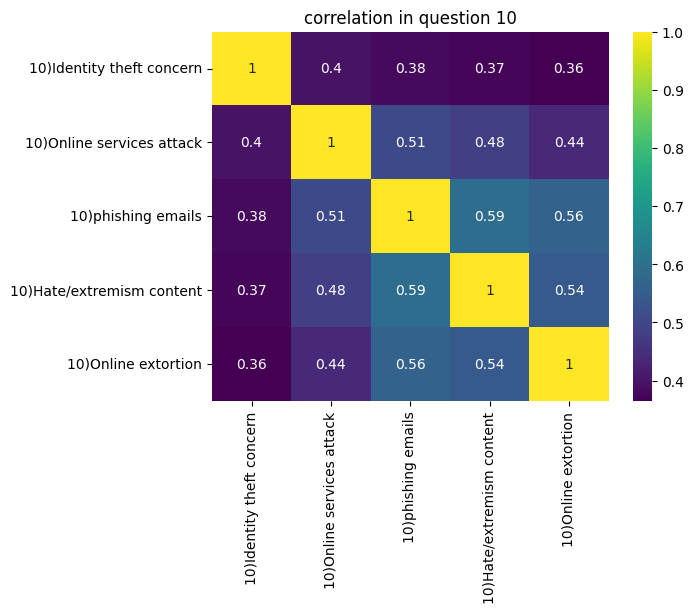

In [59]:
sns.heatmap(correlation,annot= True , cmap =  'viridis')
plt.title('correlation in question 10')

**2- Box Plot**


---



Generates a horizontal Box Plot to visualize the distribution of age midpoints (median, quartiles, and spread)

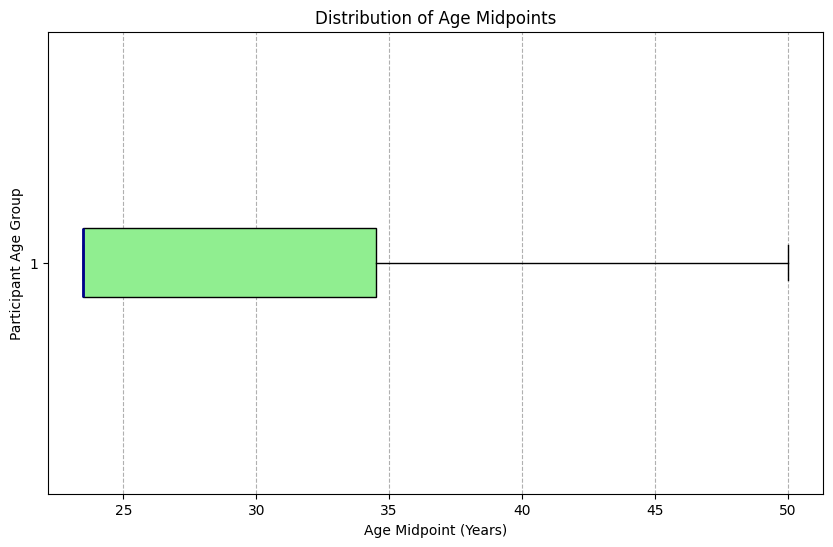

In [60]:
def age_midpoint_boxplot(df: pd.DataFrame, midpoint_col_name: str, filename: str):
  """Generates and saves a horizontal box plot showing the distribution of age midpoints from a DataFrame column"""

  plot_data = df[midpoint_col_name].tolist()
  plt.figure(figsize=(10, 6))
  plt.boxplot(plot_data,
                vert=False,
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen'),
                medianprops=dict(color='darkblue', linewidth=2))
  plt.xlabel('Age Midpoint (Years)')
  plt.ylabel('Participant Age Group')

  plt.title('Distribution of Age Midpoints')
  plt.grid(axis='x', linestyle='--')
  plt.savefig(filename)

age_midpoint_boxplot(
    df=df,
    midpoint_col_name='midpoints',
    filename='age_midpoint_green_boxplot.png'
)

**3- Pie Chart**

---

to show all different age categories

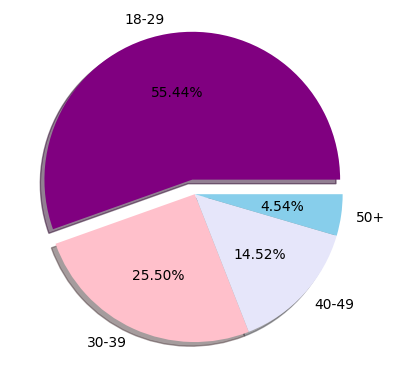

In [61]:
def age_pieCh():
  """pie chart graph shows different age categories"""

  #counting the appearance of each value
  c1=df['2)Age'].str.contains('18-29').sum()
  c2=df['2)Age'].str.contains('30-39').sum()
  c3=df['2)Age'].str.contains('40-49').sum()
  c4=df['2)Age'].str.contains('50+').sum()

  age = ['18-29', '30-39','40-49','50+']
  values = [c1,c2,c3,c4]

  explode = [0.1, 0, 0, 0]
  colors = ( "purple", "pink", "lavender",
          "skyblue")

  plt.pie(values, labels=age, explode=explode, autopct='%.2f%%',
        colors=colors, shadow=True)
  plt.show


age_pieCh()

**4- Bar Chart**


---



to visually represent these major frequencies.

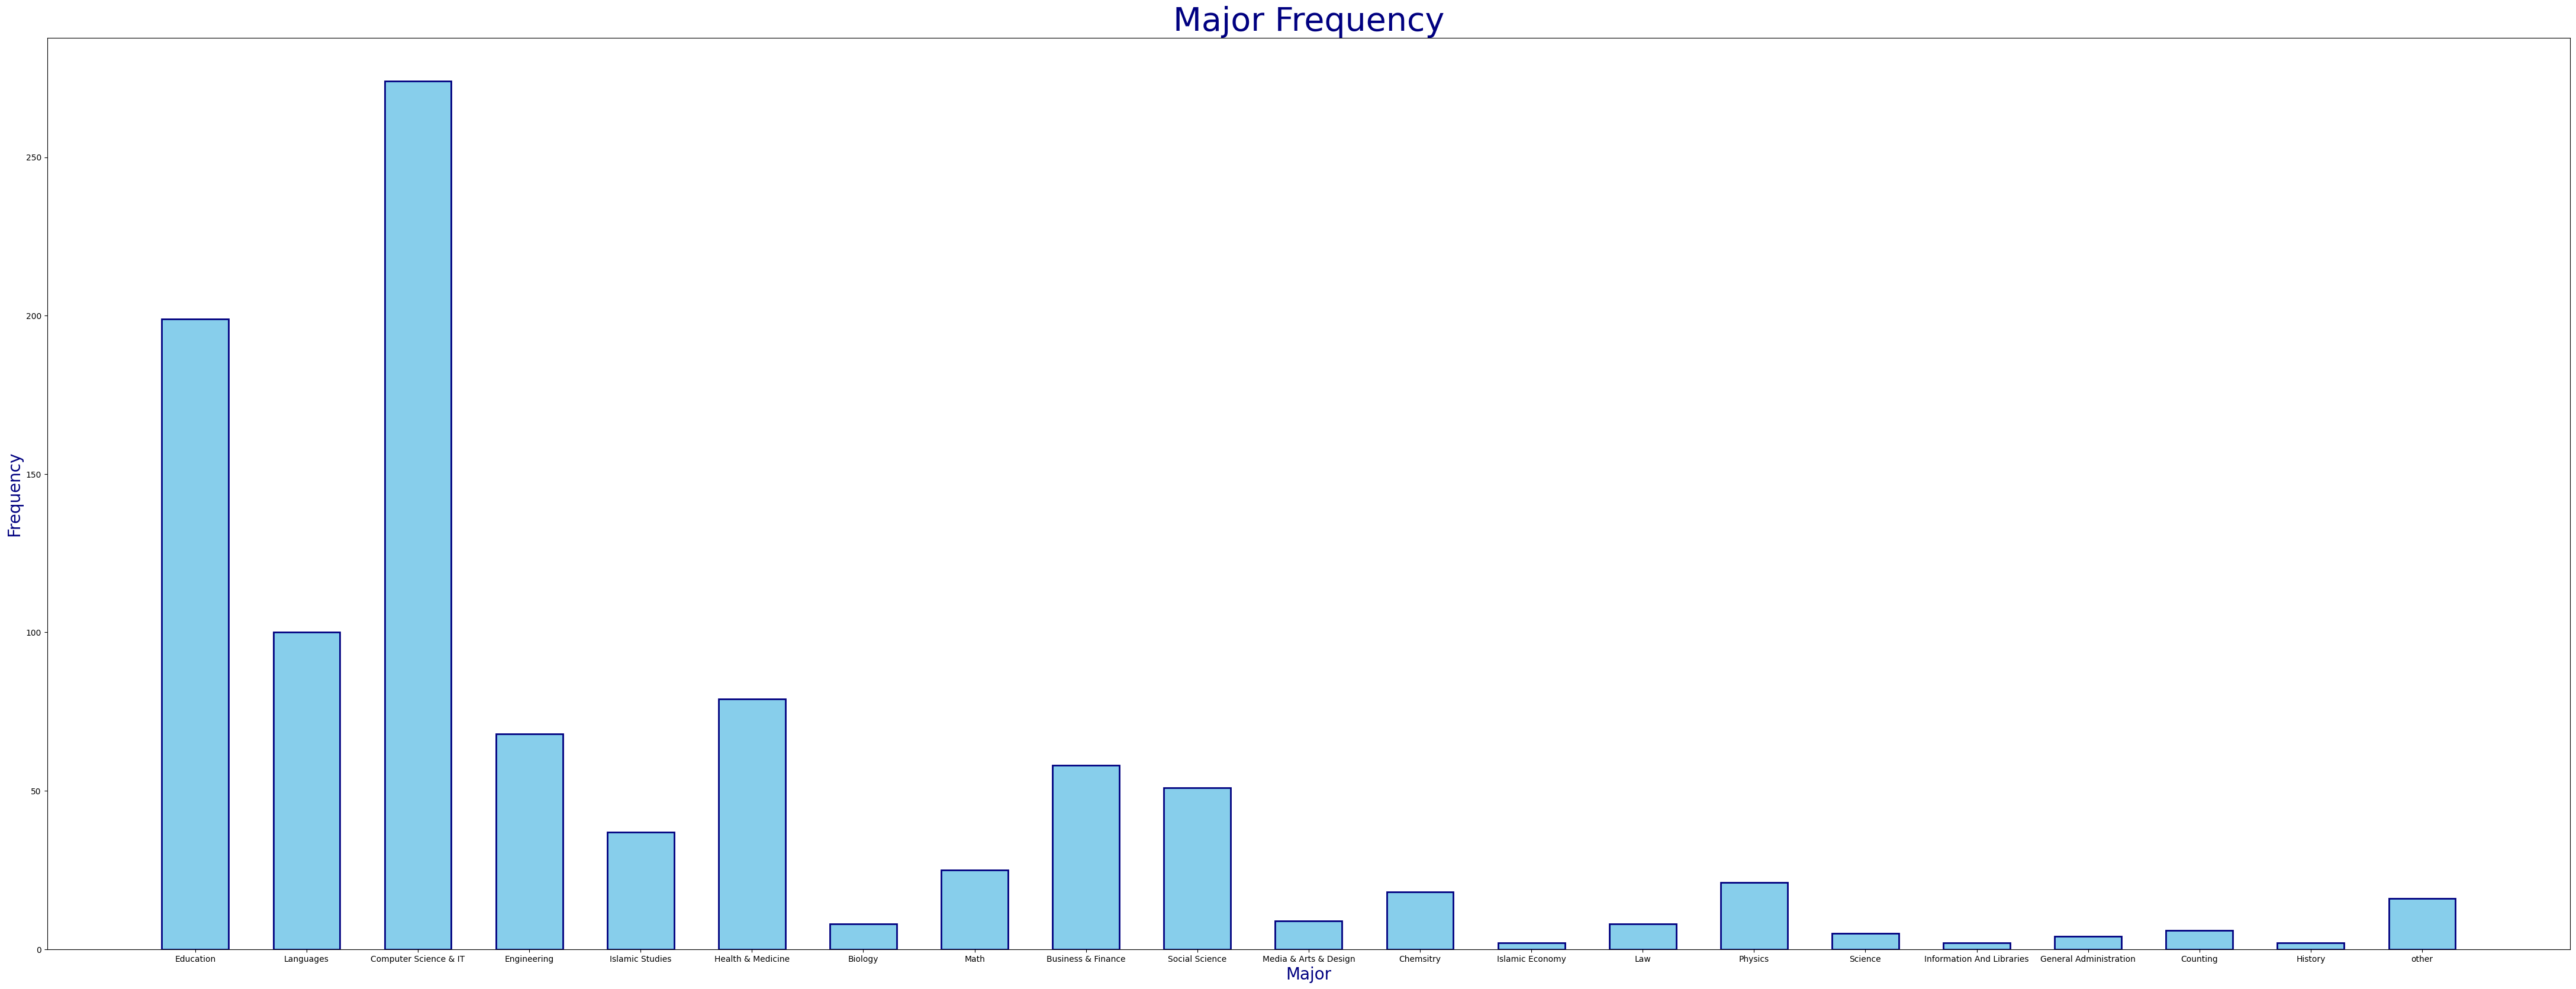

In [62]:
def major_bar(df):
   """
   Draw a bar chart showing how many students are in each major

   Steps:
   1. Count how many times each major shows up
   2. Extract the major names and their frequencies
   3. Plot the bar chart

   """
   major_dict = major_counting(df)


   main_major = [key for key, value in major_dict.items() ]
   major_freq = [value for key, value in major_dict.items() ]
   fig = plt.figure(figsize =(55, 20))

   plt.bar(main_major, major_freq,width=0.6, color='skyblue', edgecolor='navy',
           linewidth=2)
   plt.title("Major Frequency",fontsize=40, color='navy')
   plt.xlabel("Major", fontsize=20,color='navy')
   plt.ylabel("Frequency", fontsize=20,color='navy')
   plt.show()

major_bar(df)

**5- plot diagram**
___

displaying victim counts across different skill levels

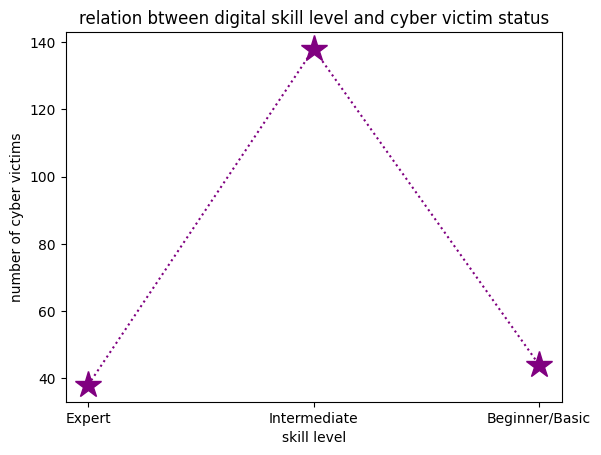

In [63]:
yes ='11)Have you been a victim of cyber crime?'
skill ='7)Digital Skills'
#creat a new df that contains only the people who experienced a cyber crime
newdf = df[df[yes] == 1][[skill]]

values = {}
#Count the number of people in each skill level who experienced a cyber crime
for i in newdf[skill] :

    if i not in values:
     values[i] = 1
    else:
     values[i] +=1


plt.plot( values.keys() , values.values() ,color='purple', marker ='*' ,markersize=20 , linestyle=':')

plt.title('relation btween digital skill level and cyber victim status')
plt.xlabel('skill level')
plt.ylabel('number of cyber victims')
plt.show()

In [64]:
newdf

,7)Digital Skills
75,Expert
80,Intermediate
84,Intermediate
87,Intermediate
91,Intermediate
...,...
1203,Intermediate
1208,Intermediate
1213,Beginner/Basic
1219,Intermediate


**6- Histogram**


---





showing the age distribution of victims and non victims

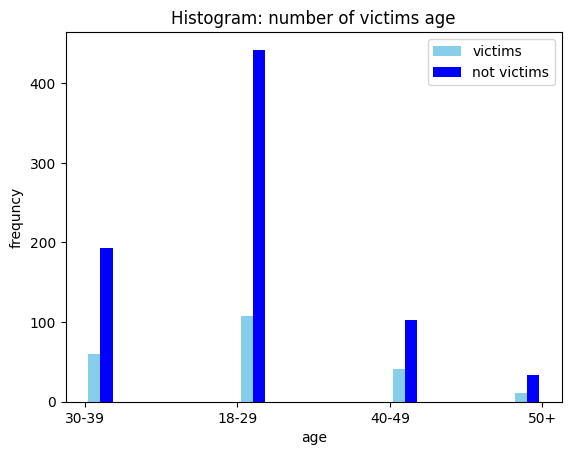

In [65]:
v = '11)Have you been a victim of cyber crime?'
age =  '2)Age'

victims= df[df[v]==1][age]  #get ages of victims
notvictims= df[df[v]==0][age] #get ages of non victims

#plot histogram
plt.hist([victims,notvictims],bins=15,color=['skyblue','blue'])
plt.legend(labels= ('victims','not victims'))

plt.title('Histogram: number of victims age')
plt.xlabel('age')
plt.ylabel('frequncy')

plt.show()

In [66]:
#print header of the data after the cleaning
df.head(10)

,1)Gender,2)Age,3)Education Level,4)Major,5)administrative regions,6)Internet usage,7)Digital Skills,8)digital devices,9)Internet Purpose,10)Identity theft concern,10)Online services attack,10)phishing emails,10)Hate/extremism content,10)Online extortion,11)Have you been a victim of cyber crime?,midpoints
71,Female,40-49,Undergraduate,Education,Makkah,Once or twice a day,Intermediate,Smartphone,Education,2,2,2,2,2,0,44.5
72,Female,30-39,Undergraduate,Education,Makkah,Frequently throughout the day,Intermediate,"Laptop, Smartphone","Professional reasons, Education, Social networ...",1,3,3,3,3,0,34.5
73,Female,18-29,Undergraduate,Languages,Asir,Frequently throughout the day,Beginner/Basic,"Laptop, Smartphone","Professional reasons, Education, Social networ...",3,3,3,3,3,0,23.5
75,Male,30-39,Postgraduate,Computer Science & IT,Makkah,Frequently throughout the day,Expert,"Desktop, Laptop, Smartphone","Education, Social networks, Online services, E...",3,3,3,3,3,1,34.5
76,Male,30-39,Undergraduate,Engineering,Riyadh,Frequently throughout the day,Intermediate,"Desktop, Smartphone","Professional reasons, Education, Online servic...",3,3,3,3,3,0,34.5
77,Female,18-29,Undergraduate,Islamic Studies,Riyadh,Frequently throughout the day,Beginner/Basic,"Desktop, Smartphone","Education, Social networks, Online services, C...",2,1,0,0,0,0,23.5
78,Female,18-29,Undergraduate,Languages,Makkah,Frequently throughout the day,Beginner/Basic,Smartphone,"Professional reasons, Education, Social networ...",3,3,3,3,3,0,23.5
79,Male,40-49,Undergraduate,Education,Makkah,Frequently throughout the day,Intermediate,Smartphone,Education,3,3,3,3,3,0,44.5
80,Male,18-29,Postgraduate,Engineering,Makkah,Frequently throughout the day,Intermediate,"Laptop, Smartphone","Education, Social networks, Online services, C...",3,3,2,3,1,1,23.5
81,Female,30-39,Postgraduate,Education,Eastern Province,Frequently throughout the day,Intermediate,"Laptop, Smartphone","Professional reasons, Education, Social networ...",2,3,3,3,3,0,34.5
